# Analiza drzava kroz vrijeme

URL https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv
Data set koji prikazuje podatke po drzavama kroz vrijeme:
- drzava - country,
- godina mjerenja - year,
- broj stanovnik - pop,
- kontinent - continent,
- ocekivani zivotni vijek - lifeExp,
- BDP po stanovniku - gdpPercap


**Pitanje**: Postoji li povezanost izmedu BDP-a po stanovniku i ocekivanog zivotnog vijeka te kako se ti pokayatelji (rezultati analize) mijenjau kroz vrijeme?

Koristiti Pandas, NumPy i Matplotlib ili druge Data Science biblioteka po zelji (trebat ce pojasniti zasto i kako se koristi).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
pd.set_option('display.float_format', '{:,.3f}'.format)

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv')
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,"8,425,333.000",Asia,28.801,779.445
1,Afghanistan,1957,"9,240,934.000",Asia,30.332,820.853
2,Afghanistan,1962,"10,267,083.000",Asia,31.997,853.101
3,Afghanistan,1967,"11,537,966.000",Asia,34.020,836.197
4,Afghanistan,1972,"13,079,460.000",Asia,36.088,739.981


In [29]:
df.shape

(1704, 6)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 80.0 KB


In [31]:
df.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

In [32]:
df.describe()

,year,pop,lifeExp,gdpPercap
count,"1,704.000","1,704.000","1,704.000","1,704.000"
mean,"1,979.500","29,601,212.325",59.474,"7,215.327"
std,17.265,"106,157,896.747",12.917,"9,857.455"
min,"1,952.000","60,011.000",23.599,241.166
25%,"1,965.750","2,793,664.000",48.198,"1,202.060"
50%,"1,979.500","7,023,595.500",60.712,"3,531.847"
75%,"1,993.250","19,585,221.750",70.846,"9,325.462"
max,"2,007.000","1,318,683,096.000",82.603,"113,523.133"


In [33]:
df.year.max()

np.int64(2007)

In [34]:
df = df.rename(
    columns={
        'country': 'drzava',
        'year': 'godina',
        'pop': 'stanovnistvo',
        'continent': 'kontinent',
        'lifeExp': 'zivotni_vijek',
        'gdpPercap': 'bdp_po_stanovniku'
    }
)

df.head()

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
0,Afghanistan,1952,"8,425,333.000",Asia,28.801,779.445
1,Afghanistan,1957,"9,240,934.000",Asia,30.332,820.853
2,Afghanistan,1962,"10,267,083.000",Asia,31.997,853.101
3,Afghanistan,1967,"11,537,966.000",Asia,34.020,836.197
4,Afghanistan,1972,"13,079,460.000",Asia,36.088,739.981


In [35]:
nelogicne_vrijednosti = df[
    (df['stanovnistvo'] <= 0) |
    (df['bdp_po_stanovniku'] <= 0) |
    (df['zivotni_vijek'] <= 0)
]

nelogicne_vrijednosti

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku


In [36]:
df.godina.min(), df.godina.max()

(np.int64(1952), np.int64(2007))

In [37]:
df.kontinent.unique()

<StringArray>
['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
Length: 5, dtype: str

In [38]:
df.drzava.nunique()

142

In [39]:
df.stanovnistvo = df.stanovnistvo.astype(dtype=np.int64)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   drzava             1704 non-null   str    
 1   godina             1704 non-null   int64  
 2   stanovnistvo       1704 non-null   int64  
 3   kontinent          1704 non-null   str    
 4   zivotni_vijek      1704 non-null   float64
 5   bdp_po_stanovniku  1704 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 80.0 KB


In [42]:
zivotni_vijek_po_godini = df.groupby('godina')['zivotni_vijek'].mean()
zivotni_vijek_po_godini

godina
1952   49.058
1957   51.507
1962   53.609
1967   55.678
1972   57.647
1977   59.570
1982   61.533
1987   63.213
1992   64.160
1997   65.015
2002   65.695
2007   67.007
Name: zivotni_vijek, dtype: float64

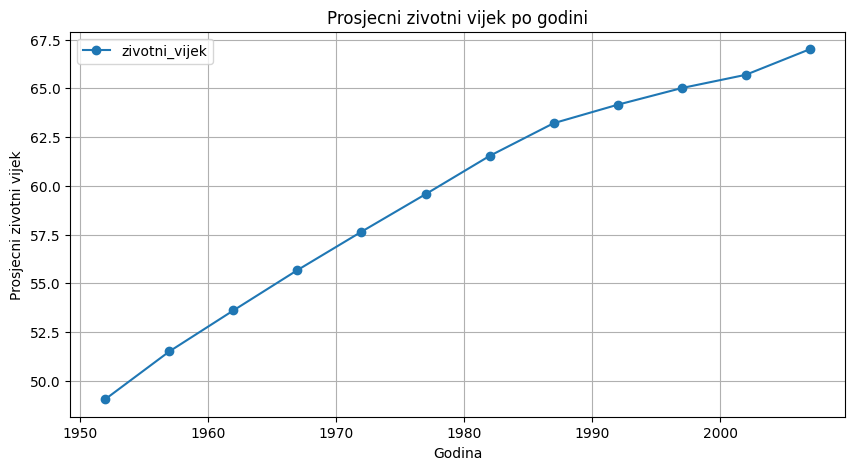

In [47]:
zivotni_vijek_po_godini.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=True,
    title='Prosjecni zivotni vijek po godini'
)

plt.xlabel('Godina')
plt.ylabel('Prosjecni zivotni vijek')
plt.grid(True)
plt.show()

In [51]:
bdp_po_godini = (
    df
    .groupby('godina')['bdp_po_stanovniku']
    .mean()
)

bdp_po_godini

godina
1952    3,725.276
1957    4,299.408
1962    4,725.812
1967    5,483.653
1972    6,770.083
1977    7,313.166
1982    7,518.902
1987    7,900.920
1992    8,158.609
1997    9,090.175
2002    9,917.848
2007   11,680.072
Name: bdp_po_stanovniku, dtype: float64

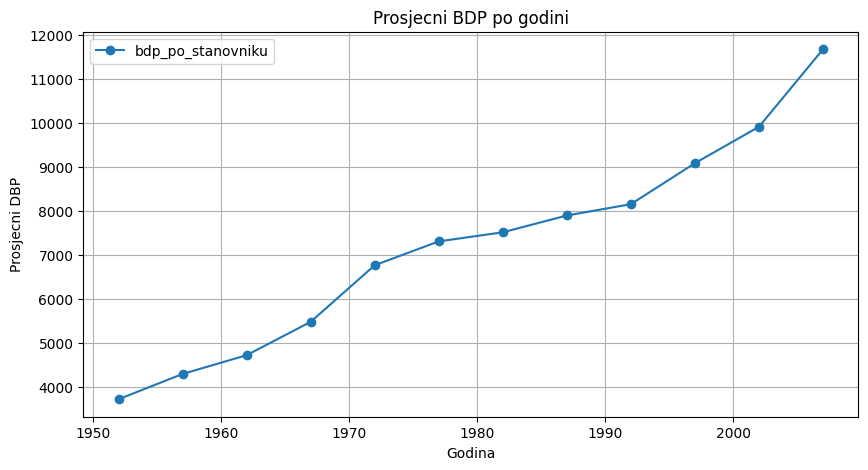

In [52]:
bdp_po_godini.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=True,
    title='Prosjecni BDP po godini'
)

plt.xlabel('Godina')
plt.ylabel('Prosjecni DBP')
plt.grid(True)
plt.show()

In [54]:
analiza_po_kontinentu = (
    df
    .groupby('kontinent')
    .agg(
        prosjecni_zivotni_vijek=('zivotni_vijek', 'mean'),
        prosjecni_bdp_po_stanovniku=('bdp_po_stanovniku', 'mean'),
        prosjecno_stanovnistvo=('stanovnistvo', 'mean'),
        broj_drzava=('drzava', 'nunique'),
    )
    .sort_values('prosjecni_zivotni_vijek', ascending=True)
)

analiza_po_kontinentu

,prosjecni_zivotni_vijek,prosjecni_bdp_po_stanovniku,prosjecno_stanovnistvo,broj_drzava
kontinent,,,,
Africa,48.865,"2,193.755","9,916,003.143",52
Asia,60.065,"7,902.150","77,038,721.975",33
Americas,64.659,"7,136.110","24,504,794.997",25
Europe,71.904,"14,469.476","17,169,764.733",30
Oceania,74.326,"18,621.609","8,874,672.333",2


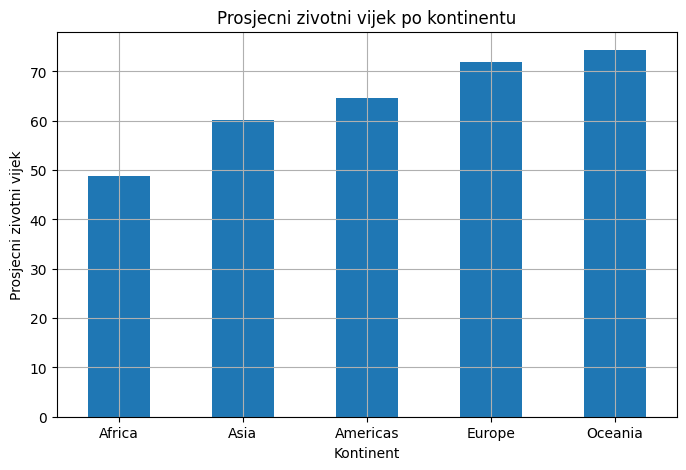

In [61]:
analiza_po_kontinentu['prosjecni_zivotni_vijek'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Prosjecni zivotni vijek po kontinentu'
)

plt.xlabel('Kontinent')
plt.ylabel('Prosjecni zivotni vijek')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

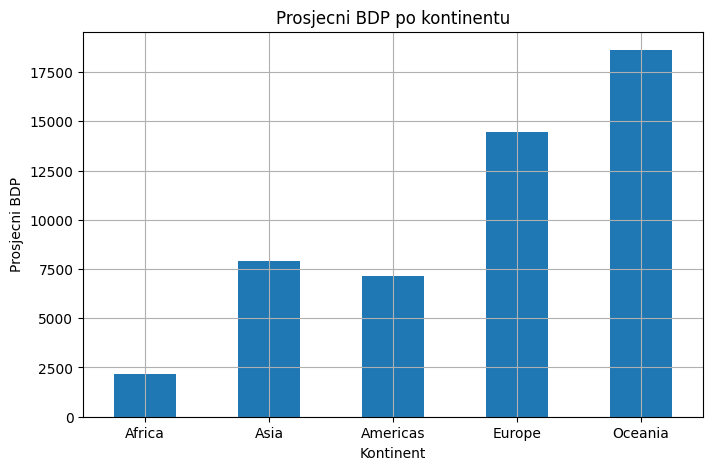

In [62]:
analiza_po_kontinentu['prosjecni_bdp_po_stanovniku'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Prosjecni BDP po kontinentu'
)

plt.xlabel('Kontinent')
plt.ylabel('Prosjecni BDP')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [63]:
zadnja_godina = df.godina.max()
zadnja_godina

np.int64(2007)

In [65]:
df_zadnja = df[df['godina'] == zadnja_godina].copy()
df_zadnja.head()

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
11,Afghanistan,2007,31889923,Asia,43.828,974.580
23,Albania,2007,3600523,Europe,76.423,"5,937.030"
35,Algeria,2007,33333216,Africa,72.301,"6,223.367"
47,Angola,2007,12420476,Africa,42.731,"4,797.231"
59,Argentina,2007,40301927,Americas,75.320,"12,779.380"


In [66]:
df_zadnja.sort_values('zivotni_vijek', ascending=False).head(10)

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
803,Japan,2007,127467972,Asia,82.603,"31,656.068"
671,"Hong Kong, China",2007,6980412,Asia,82.208,"39,724.979"
695,Iceland,2007,301931,Europe,81.757,"36,180.789"
1487,Switzerland,2007,7554661,Europe,81.701,"37,506.419"
71,Australia,2007,20434176,Oceania,81.235,"34,435.367"
1427,Spain,2007,40448191,Europe,80.941,"28,821.064"
1475,Sweden,2007,9031088,Europe,80.884,"33,859.748"
767,Israel,2007,6426679,Asia,80.745,"25,523.277"
539,France,2007,61083916,Europe,80.657,"30,470.017"
251,Canada,2007,33390141,Americas,80.653,"36,319.235"


In [67]:
df_zadnja.sort_values('bdp_po_stanovniku', ascending=False).head(10)

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
1151,Norway,2007,4627926,Europe,80.196,"49,357.190"
863,Kuwait,2007,2505559,Asia,77.588,"47,306.990"
1367,Singapore,2007,4553009,Asia,79.972,"47,143.180"
1619,United States,2007,301139947,Americas,78.242,"42,951.653"
755,Ireland,2007,4109086,Europe,78.885,"40,675.996"
671,"Hong Kong, China",2007,6980412,Asia,82.208,"39,724.979"
1487,Switzerland,2007,7554661,Europe,81.701,"37,506.419"
1091,Netherlands,2007,16570613,Europe,79.762,"36,797.933"
251,Canada,2007,33390141,Americas,80.653,"36,319.235"
695,Iceland,2007,301931,Europe,81.757,"36,180.789"


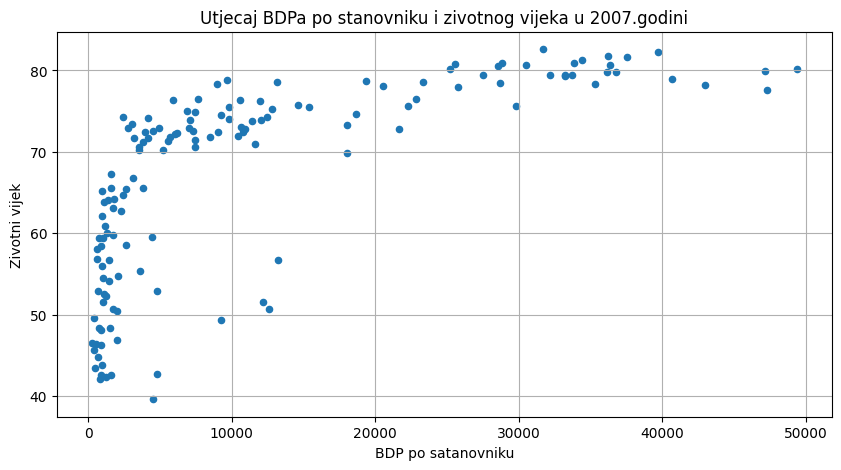

In [69]:
df_zadnja.plot(
    kind='scatter',
    x='bdp_po_stanovniku',
    y='zivotni_vijek',
    figsize=(10, 5),
    title=f'Utjecaj BDPa po stanovniku i zivotnog vijeka u {zadnja_godina}.godini'
)

plt.xlabel('BDP po satanovniku')
plt.ylabel('Zivotni vijek')
plt.grid(True)
plt.show()

In [70]:
df_zadnja['log_bdp_po_stanovniku'] = np.log(df_zadnja['bdp_po_stanovniku'])

df_zadnja[['drzava', 'bdp_po_stanovniku', 'log_bdp_po_stanovniku', 'zivotni_vijek']].head(10)

,drzava,bdp_po_stanovniku,log_bdp_po_stanovniku,zivotni_vijek
11,Afghanistan,974.580,6.882,43.828
23,Albania,"5,937.030",8.689,76.423
35,Algeria,"6,223.367",8.736,72.301
47,Angola,"4,797.231",8.476,42.731
59,Argentina,"12,779.380",9.456,75.320
71,Australia,"34,435.367",10.447,81.235
83,Austria,"36,126.493",10.495,79.829
95,Bahrain,"29,796.048",10.302,75.635
107,Bangladesh,"1,391.254",7.238,64.062
119,Belgium,"33,692.605",10.425,79.441


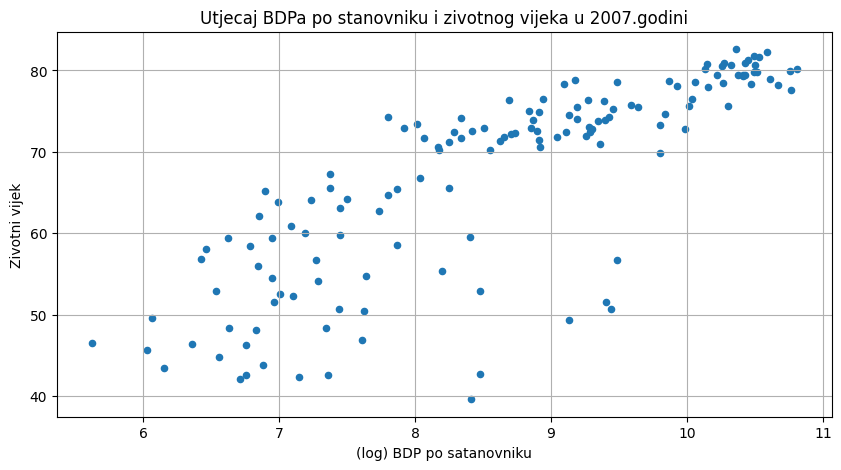

In [71]:
df_zadnja.plot(
    kind='scatter',
    x='log_bdp_po_stanovniku',
    y='zivotni_vijek',
    figsize=(10, 5),
    title=f'Utjecaj BDPa po stanovniku i zivotnog vijeka u {zadnja_godina}.godini'
)

plt.xlabel('(log) BDP po satanovniku')
plt.ylabel('Zivotni vijek')
plt.grid(True)
plt.show()

In [75]:
korelacija = df_zadnja['bdp_po_stanovniku'].corr(df_zadnja['zivotni_vijek'])
korelacija

korelacija_log = df_zadnja['log_bdp_po_stanovniku'].corr(df_zadnja['zivotni_vijek'])
korelacija_log

np.float64(0.8089802514849211)

In [78]:
hrvatska = df[df['drzava'] == 'Croatia'].copy()
hrvatska

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
372,Croatia,1952,3882229,Europe,61.210,"3,119.237"
373,Croatia,1957,3991242,Europe,64.770,"4,338.232"
374,Croatia,1962,4076557,Europe,67.130,"5,477.890"
375,Croatia,1967,4174366,Europe,68.500,"6,960.298"
376,Croatia,1972,4225310,Europe,69.610,"9,164.090"
377,Croatia,1977,4318673,Europe,70.640,"11,305.385"
378,Croatia,1982,4413368,Europe,70.460,"13,221.822"
379,Croatia,1987,4484310,Europe,71.520,"13,822.584"
380,Croatia,1992,4494013,Europe,72.527,"8,447.795"
381,Croatia,1997,4444595,Europe,73.680,"9,875.605"


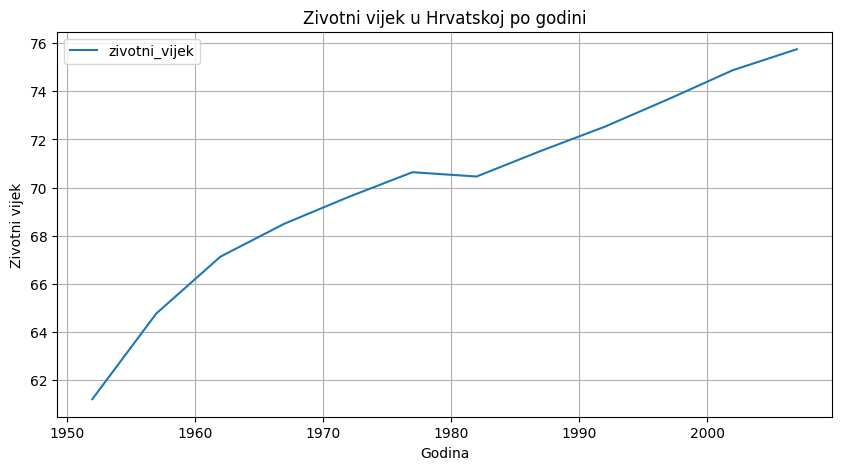

In [81]:
hrvatska.plot(
    kind='line',
    x='godina',
    y='zivotni_vijek',
    figsize=(10, 5),
    title=f'Zivotni vijek u Hrvatskoj po godini'
)

plt.xlabel('Godina')
plt.ylabel('Zivotni vijek')
plt.grid(True)
plt.show()

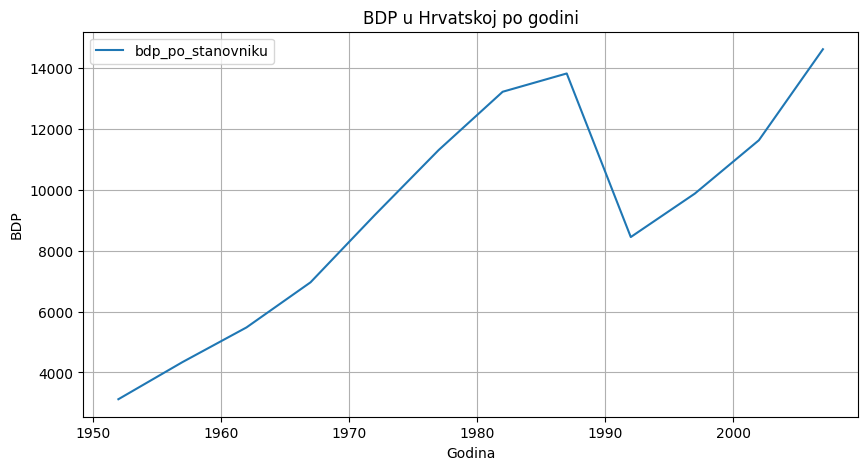

In [82]:
hrvatska.plot(
    kind='line',
    x='godina',
    y='bdp_po_stanovniku',
    figsize=(10, 5),
    title=f'BDP u Hrvatskoj po godini'
)

plt.xlabel('Godina')
plt.ylabel('BDP')
plt.grid(True)
plt.show()